In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import *
import requests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
import warnings
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
import torch.optim as optim
from xgboost import train
import CONSTANTS
from functions import *
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import clone
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from xgboostImplementation import XGBoost
import pickle
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')

In [42]:
data = pd.read_csv(fullDataPath(COIN))
data = data.loc[:, ~data.columns.str.contains('^Unnamed:')]
merged = dataSetup(data)
merged

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,close,gradient
time,,,,,,,,,,
2024-06-27,54298.361946,65288.365054,45.0,0.000000,10530.358988,-273098.307712,61499.718571,9207.959382,61615.39,798.71
2024-06-28,54145.327791,65688.441209,46.0,0.000000,11381.025874,-283628.666701,60846.397143,10270.673373,60313.35,-1302.04
2024-06-29,54049.203970,66151.516030,44.0,0.000000,3199.036501,-272247.640827,60321.551429,12652.300393,60885.67,572.32
2024-06-30,53659.403029,67123.510971,45.0,0.000000,4263.229248,-269048.604326,59944.277143,13116.627323,62668.26,1782.59
2024-07-01,53290.098982,67942.372018,49.0,0.000000,12326.706965,-264785.375077,58970.824286,13267.725496,62830.13,161.87
...,...,...,...,...,...,...,...,...,...,...
2025-06-22,101255.903690,110442.214310,40.0,3.116564,7872.258744,-15479.804635,104624.465714,0.000000,100996.87,-1163.16
2025-06-23,101255.903690,110442.214310,37.0,-3.693263,8904.624392,-7607.545890,104624.465714,0.000000,105419.39,4422.52
2025-06-24,101255.903690,110442.214310,47.0,1.941039,5773.171996,1297.078502,104624.465714,0.000000,106141.00,721.61


# XGBoost Implementation

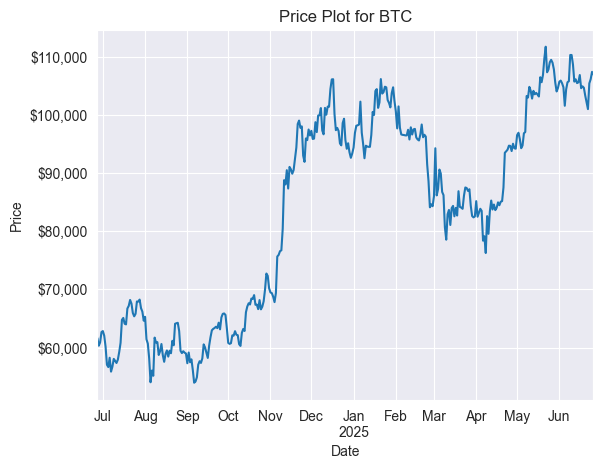

In [43]:
merged['close'].plot.line()
plt.title(f'Price Plot for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
# format y axis to show currency
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

In [44]:
scaler = StandardScaler()
closeScaler = StandardScaler()
mergedIndex = merged.index
mergedCols = merged.columns

mergedWithoutClose = merged.drop(columns=['close'])
mwocCols = mergedWithoutClose.columns
mwocIndex = mergedWithoutClose.index
mergedWithoutClose = scaler.fit_transform(mergedWithoutClose)
mergedWithoutClose = pd.DataFrame(mergedWithoutClose, index=mergedIndex, columns=mwocCols)

merged['close'] = closeScaler.fit_transform(merged['close'].values.reshape(-1, 1))
merged = pd.concat([mergedWithoutClose, merged['close']], axis=1)
merged

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,gradient,close
time,,,,,,,,,,
2024-06-27,-1.382689,-1.502640,-0.347445,-0.040228,-0.019746,-1.555176,-1.292917,-0.290918,0.318391,-1.254099
2024-06-28,-1.391569,-1.479616,-0.288018,-0.040228,0.091976,-1.654198,-1.330631,-0.061024,-0.676410,-1.328562
2024-06-29,-1.397146,-1.452966,-0.406872,-0.040228,-0.982605,-1.547176,-1.360929,0.454185,0.211185,-1.295831
2024-06-30,-1.419765,-1.397028,-0.347445,-0.040228,-0.842839,-1.517094,-1.382708,0.554632,0.784304,-1.193886
2024-07-01,-1.441194,-1.349903,-0.109736,-0.040228,0.216177,-1.477005,-1.438903,0.587318,0.016818,-1.184629
...,...,...,...,...,...,...,...,...,...,...
2025-06-22,1.342041,1.095957,-0.644580,0.591732,-0.368848,0.867346,1.196553,-2.282845,-0.610644,0.998106
2025-06-23,1.342041,1.095957,-0.822861,-0.789128,-0.233262,0.941373,1.196553,-2.282845,2.034431,1.251027
2025-06-24,1.342041,1.095957,-0.228591,0.353366,-0.644531,1.025108,1.196553,-2.282845,0.281881,1.292296


In [36]:
training_cols = trainingCols()
X = merged[training_cols]
y = merged['close']
n = len(data)

merged = transformerDataSetup(merged)
X_train, X_test, y_train, y_test, _, _ = transformerXTrainYTrain(merged[-LIMIT:], testSize=len(merged)-TEST_DAYS)
train_stuff = merged.loc[X_train.index, training_cols]
test_stuff = merged.loc[X_test.index, training_cols]
X_train_norm = pd.concat([X_train, train_stuff], axis=1)
X_test_norm = pd.concat([X_test, test_stuff], axis=1)

X_train_norm.shape, X_test_norm.shape, y_train.shape, y_test.shape

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [20]:
xgb_model = XGBoost(
    base_estimator=RandomForestRegressor(n_estimators=50),
    n_estimators=50,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
)

RMSE = 2841.8629012593633


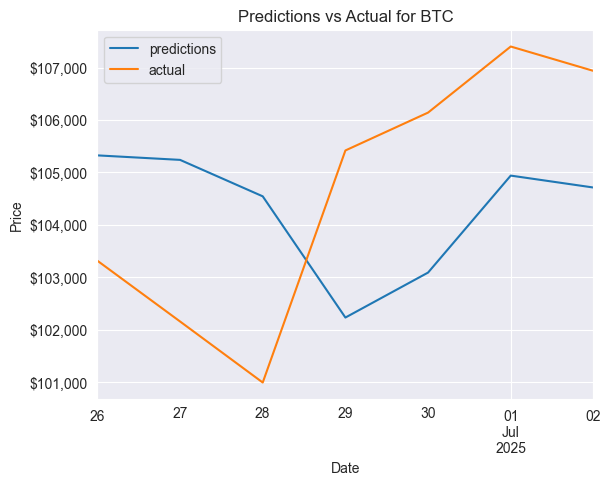

In [59]:
xgb_model.fit(X_train_norm, y_train)
predictions = xgb_model.predict(X_test_norm.iloc[[-1]])
xgb_model.save(f'models/{COIN}_full_xgb_model.pkl')

predictions = np.array(predictions)
predictions = predictions.reshape(-1, 1)
predictions = closeScaler.inverse_transform(predictions)
predictions = pd.DataFrame(predictions, columns=['predictions'])
predictions['actual'] = closeScaler.inverse_transform(merged['close'].iloc[-TEST_DAYS:].values.reshape(-1, 1))
predictions.index = pd.date_range(start=merged.index.max(), periods=TEST_DAYS, freq='D')

predictions.plot.line()
plt.title(f'Predictions vs Actual for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))
print('RMSE =', mean_squared_error(predictions['actual'], predictions['predictions'], squared=False))
plt.show()